In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.18.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
DATASET_PATH = "flowers"

CLASS_NAMES = ["daisy", "rose"]

class_to_label = {
    "daisy": 0,
    "rose": 1
}

print(class_to_label)

{'daisy': 0, 'rose': 1}


In [3]:
rows = []

for class_name in CLASS_NAMES:

    folder = os.path.join(
        DATASET_PATH,
        class_name
    )

    paths = []

    for ext in [
        "*.jpg",
        "*.jpeg",
        "*.png",
        "*.JPG",
        "*.JPEG",
        "*.PNG"
    ]:
        paths.extend(
            glob.glob(
                os.path.join(folder, ext)
            )
        )

    for path in paths:
        rows.append({
            "path": path,
            "class_name": class_name,
            "label": class_to_label[class_name]
        })

df = pd.DataFrame(rows)

print("Total images:", len(df))

print(
    df["class_name"].value_counts()
)

df.head()

Total images: 1548
class_name
rose     784
daisy    764
Name: count, dtype: int64


,path,class_name,label
0,flowers/daisy/14167534527_781ceb1b7a_n.jpg,daisy,0
1,flowers/daisy/34718882165_68cdc9def9_n.jpg,daisy,0
2,flowers/daisy/5512287917_9f5d3f0f98_n.jpg,daisy,0
3,flowers/daisy/476857510_d2b30175de_n.jpg,daisy,0
4,flowers/daisy/521762040_f26f2e08dd.jpg,daisy,0


In [4]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain classes:")
print(train_df["class_name"].value_counts())

print("\nValidation classes:")
print(val_df["class_name"].value_counts())

print("\nTest classes:")
print(test_df["class_name"].value_counts())

Train: 1083
Validation: 232
Test: 233

Train classes:
class_name
rose     548
daisy    535
Name: count, dtype: int64

Validation classes:
class_name
rose     118
daisy    114
Name: count, dtype: int64

Test classes:
class_name
rose     118
daisy    115
Name: count, dtype: int64


In [5]:
IMG_HEIGHT = 100
IMG_WIDTH = 100
BATCH_SIZE = 16

AUTOTUNE = tf.data.AUTOTUNE

In [6]:
def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape(
        [None, None, 3]
    )

    image = tf.image.resize(
        image,
        [IMG_HEIGHT, IMG_WIDTH]
    )

    image = tf.cast(
        image,
        tf.float32
    )

    label = tf.cast(
        label,
        tf.float32
    )

    return image, label

In [7]:
def make_dataset(
    dataframe,
    training=False
):

    paths = dataframe["path"].values
    labels = dataframe["label"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset

In [8]:
train_ds = make_dataset(
    train_df,
    training=True
)

val_ds = make_dataset(
    val_df,
    training=False
)

test_ds = make_dataset(
    test_df,
    training=False
)

2026-09-27 17:01:26.596523: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-09-27 17:01:26.596799: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-09-27 17:01:26.596824: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
I0000 00:00:1790508686.597375   22347 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1790508686.597750   22347 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [9]:
images, labels = next(
    iter(train_ds)
)

print("Image batch:", images.shape)
print("Label batch:", labels.shape)

print(
    "Pixel range:",
    tf.reduce_min(images).numpy(),
    tf.reduce_max(images).numpy()
)

Image batch: (16, 100, 100, 3)
Label batch: (16,)
Pixel range: 0.0 255.0


2026-09-27 17:01:27.605582: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


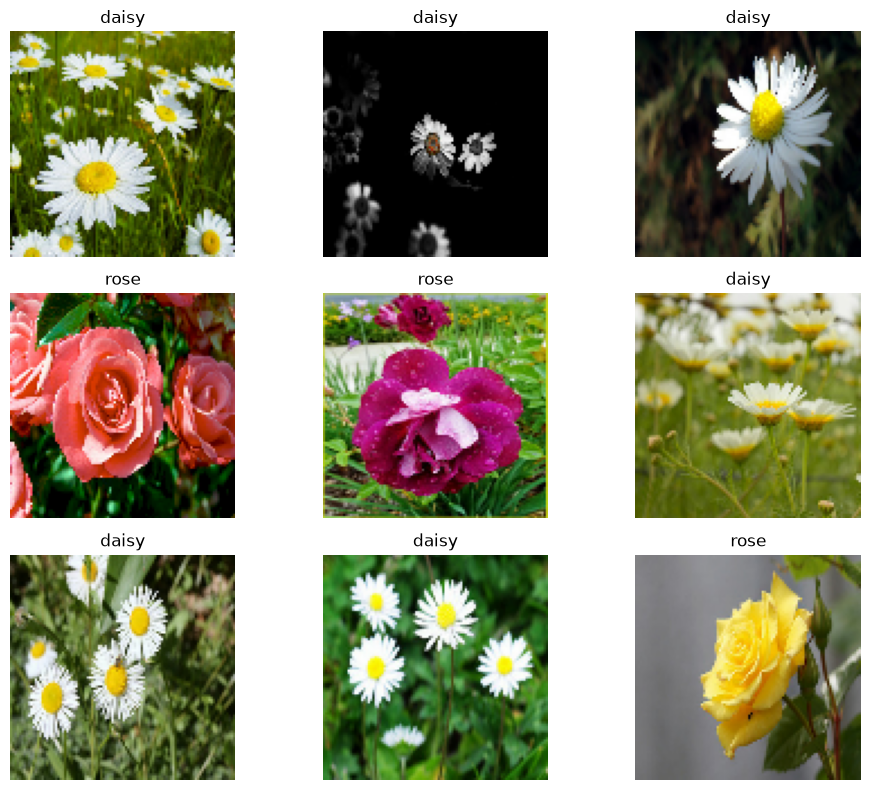

In [10]:
plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):

    for i in range(
        min(9, len(images))
    ):

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        label = int(
            labels[i].numpy()
        )

        plt.title(
            CLASS_NAMES[label]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(
        "horizontal"
    ),

    tf.keras.layers.RandomRotation(
        0.08
    ),

    tf.keras.layers.RandomZoom(
        0.10
    ),

    tf.keras.layers.RandomTranslation(
        height_factor=0.08,
        width_factor=0.08
    )
])

In [12]:
try:

    base_model = tf.keras.applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(
            IMG_HEIGHT,
            IMG_WIDTH,
            3
        )
    )

    print("Loaded ImageNet weights.")

except Exception as e:

    print(
        "Could not load ImageNet weights."
    )

    print(e)

    base_model = tf.keras.applications.ResNet50(
        weights=None,
        include_top=False,
        input_shape=(
            IMG_HEIGHT,
            IMG_WIDTH,
            3
        )
    )

Loaded ImageNet weights.


In [13]:
base_model.trainable = False

In [14]:
inputs = tf.keras.Input(
    shape=(
        IMG_HEIGHT,
        IMG_WIDTH,
        3
    )
)

x = data_augmentation(
    inputs
)

x = tf.keras.applications.resnet50.preprocess_input(
    x
)

x = base_model(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(
    x
)

x = tf.keras.layers.Dropout(
    0.30
)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.Model(
    inputs,
    outputs
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 100, 100,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 100, 100)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 100, 100)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 100, 100)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 100, 100,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 100, 100,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 4, 4,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [15]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

model.compile(
    optimizer=optimizer,

    loss=tf.keras.losses.BinaryCrossentropy(),

    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)

In [16]:
os.makedirs(
    "models",
    exist_ok=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "models/best_daisy_rose.keras",

    monitor="val_auc",

    mode="max",

    save_best_only=True,

    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",

    mode="max",

    patience=4,

    restore_best_weights=True,

    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",

    factor=0.5,

    patience=2,

    min_lr=1e-6,

    verbose=1
)

In [17]:
history = model.fit(
    train_ds,

    validation_data=val_ds,

    epochs=15,

    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr
    ]
)

Epoch 1/15


/opt/anaconda3/envs/melanoma_gpu/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-09-27 17:01:30.175098: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7932 - auc: 0.8908 - loss: 0.4088
Epoch 1: val_auc improved from None to 0.97339, saving model to models/best_daisy_rose.keras

Epoch 1: finished saving model to models/best_daisy_rose.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 16s 152ms/step - accuracy: 0.7932 - auc: 0.8908 - loss: 0.4088 - val_accuracy: 0.9095 - val_auc: 0.9734 - val_loss: 0.2216 - learning_rate: 0.0010
Epoch 2/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9123 - auc: 0.9650 - loss: 0.2388
Epoch 2: val_auc improved from 0.97339 to 0.98075, saving model to models/best_daisy_rose.keras

Epoch 2: finished saving model to models/best_daisy_rose.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.9123 - auc: 0.9650 - loss: 0.2388 - val_accuracy: 0.9224 - val_auc: 0.9807 - val_loss: 0.2053 - learning_rate: 0.0010
Epoch 3/15
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9151 - auc: 0.9714 - loss: 0.2121
Epoch 3: val_auc improved from 0.98075 to 0.98405, 

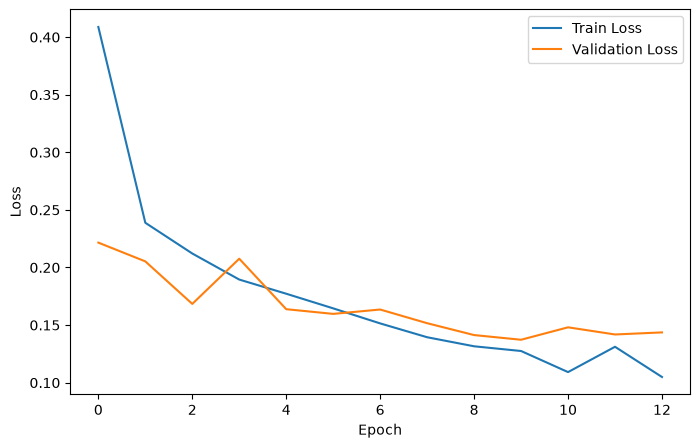

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

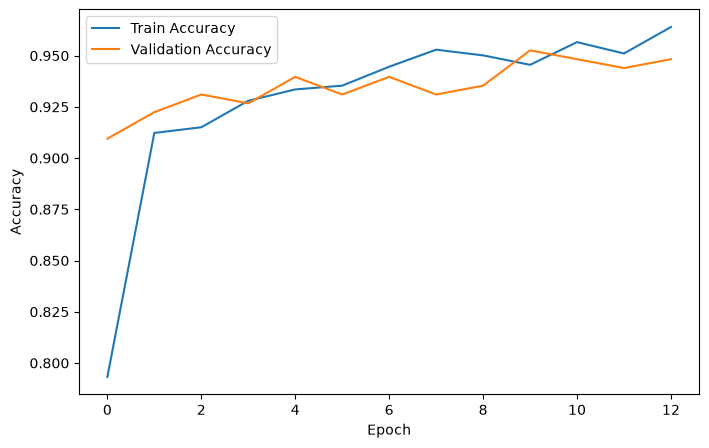

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

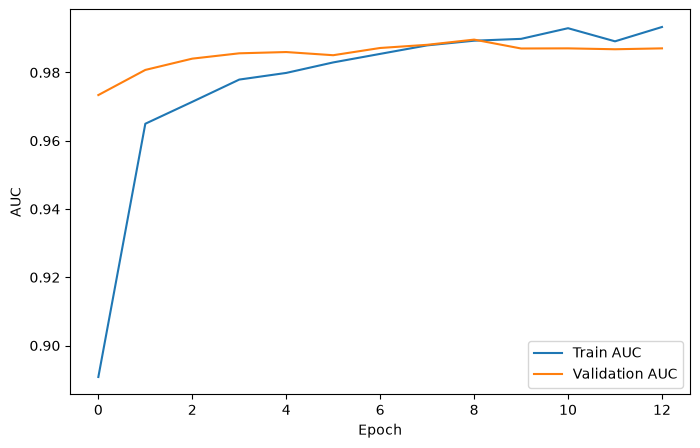

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["auc"],
    label="Train AUC"
)

plt.plot(
    history.history["val_auc"],
    label="Validation AUC"
)

plt.xlabel("Epoch")
plt.ylabel("AUC")

plt.legend()

plt.show()

In [25]:
best_model = tf.keras.models.load_model(
    "models/best_daisy_rose.keras"
)

print(
    "Best model loaded."
)

Best model loaded.


In [26]:
train_results = best_model.evaluate(
    train_ds,
    verbose=1
)

print("\nTRAIN RESULTS")

print(
    "Loss:",
    train_results[0]
)

print(
    "Accuracy:",
    train_results[1]
)

print(
    "AUC:",
    train_results[2]
)

68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.9705 - auc: 0.9962 - loss: 0.0778

TRAIN RESULTS
Loss: 0.0777554139494896
Accuracy: 0.9704524278640747
AUC: 0.9962378144264221


In [27]:
val_results = best_model.evaluate(
    val_ds,
    verbose=1
)

print("\nVALIDATION RESULTS")

print(
    "Loss:",
    val_results[0]
)

print(
    "Accuracy:",
    val_results[1]
)

print(
    "AUC:",
    val_results[2]
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.9353 - auc: 0.9896 - loss: 0.1413

VALIDATION RESULTS
Loss: 0.14132633805274963
Accuracy: 0.9353448152542114
AUC: 0.9896297454833984


In [28]:
test_results = best_model.evaluate(
    test_ds,
    verbose=1
)

print("\nFINAL TEST RESULTS")

print(
    "Test Loss:",
    test_results[0]
)

print(
    "Test Accuracy:",
    test_results[1]
)

print(
    "Test AUC:",
    test_results[2]
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - accuracy: 0.9485 - auc: 0.9888 - loss: 0.1292

FINAL TEST RESULTS
Test Loss: 0.12921851873397827
Test Accuracy: 0.9484978318214417
Test AUC: 0.9887988567352295


In [29]:
test_probabilities = best_model.predict(
    test_ds,
    verbose=1
).ravel()

test_predictions = (
    test_probabilities >= 0.5
).astype(int)

test_true = np.concatenate(
    [
        labels.numpy()
        for _, labels in test_ds
    ]
).astype(int)

print(
    "ROC AUC:",
    roc_auc_score(
        test_true,
        test_probabilities
    )
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 193ms/step
ROC AUC: 0.991304347826087


2026-09-27 17:05:45.006177: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [30]:
print(
    classification_report(
        test_true,
        test_predictions,
        target_names=CLASS_NAMES,
        digits=4
    )
)

              precision    recall  f1-score   support

       daisy     0.9558    0.9391    0.9474       115
        rose     0.9417    0.9576    0.9496       118

    accuracy                         0.9485       233
   macro avg     0.9487    0.9484    0.9485       233
weighted avg     0.9486    0.9485    0.9485       233



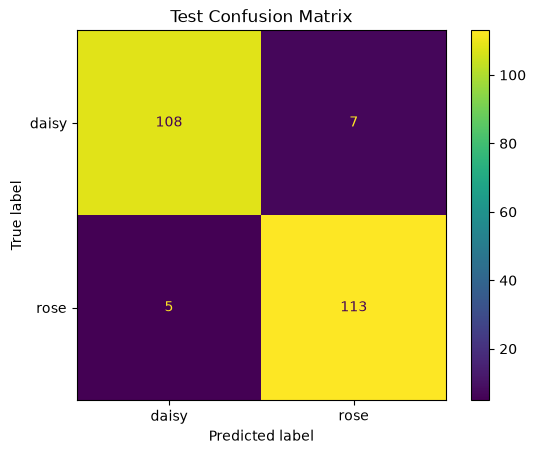

In [31]:
cm = confusion_matrix(
    test_true,
    test_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

disp.plot()

plt.title(
    "Test Confusion Matrix"
)

plt.show()

In [32]:
print(
    "TRAIN ACCURACY:",
    round(train_results[1], 4)
)

print(
    "TEST ACCURACY:",
    round(test_results[1], 4)
)

print()

print(
    "TRAIN AUC:",
    round(train_results[2], 4)
)

print(
    "TEST AUC:",
    round(test_results[2], 4)
)

print()

print(
    "TRAIN LOSS:",
    round(train_results[0], 4)
)

print(
    "TEST LOSS:",
    round(test_results[0], 4)
)

TRAIN ACCURACY: 0.9705
TEST ACCURACY: 0.9485

TRAIN AUC: 0.9962
TEST AUC: 0.9888

TRAIN LOSS: 0.0778
TEST LOSS: 0.1292


In [33]:
sample = test_df.sample(
    1,
    random_state=10
).iloc[0]

sample_path = sample["path"]

actual_class = sample["class_name"]

print(
    "Image:",
    sample_path
)

print(
    "Actual:",
    actual_class
)

Image: flowers/rose/5835539224_75967fc400_m.jpg
Actual: rose


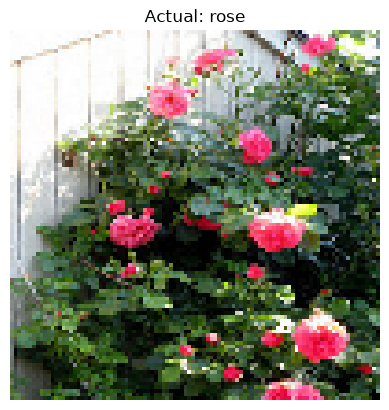

In [34]:
image = tf.keras.utils.load_img(
    sample_path,
    target_size=(
        IMG_HEIGHT,
        IMG_WIDTH
    )
)

plt.imshow(image)

plt.title(
    f"Actual: {actual_class}"
)

plt.axis("off")

plt.show()

In [35]:
image_array = tf.keras.utils.img_to_array(
    image
)

image_array = np.expand_dims(
    image_array,
    axis=0
)

rose_probability = float(
    best_model.predict(
        image_array,
        verbose=0
    )[0][0]
)

daisy_probability = (
    1.0 - rose_probability
)

if rose_probability >= 0.5:
    predicted_class = "rose"
else:
    predicted_class = "daisy"

print(
    "Daisy probability:",
    round(
        daisy_probability,
        4
    )
)

print(
    "Rose probability:",
    round(
        rose_probability,
        4
    )
)

print(
    "Predicted:",
    predicted_class
)

print(
    "Actual:",
    actual_class
)

Daisy probability: 0.0037
Rose probability: 0.9963
Predicted: rose
Actual: rose


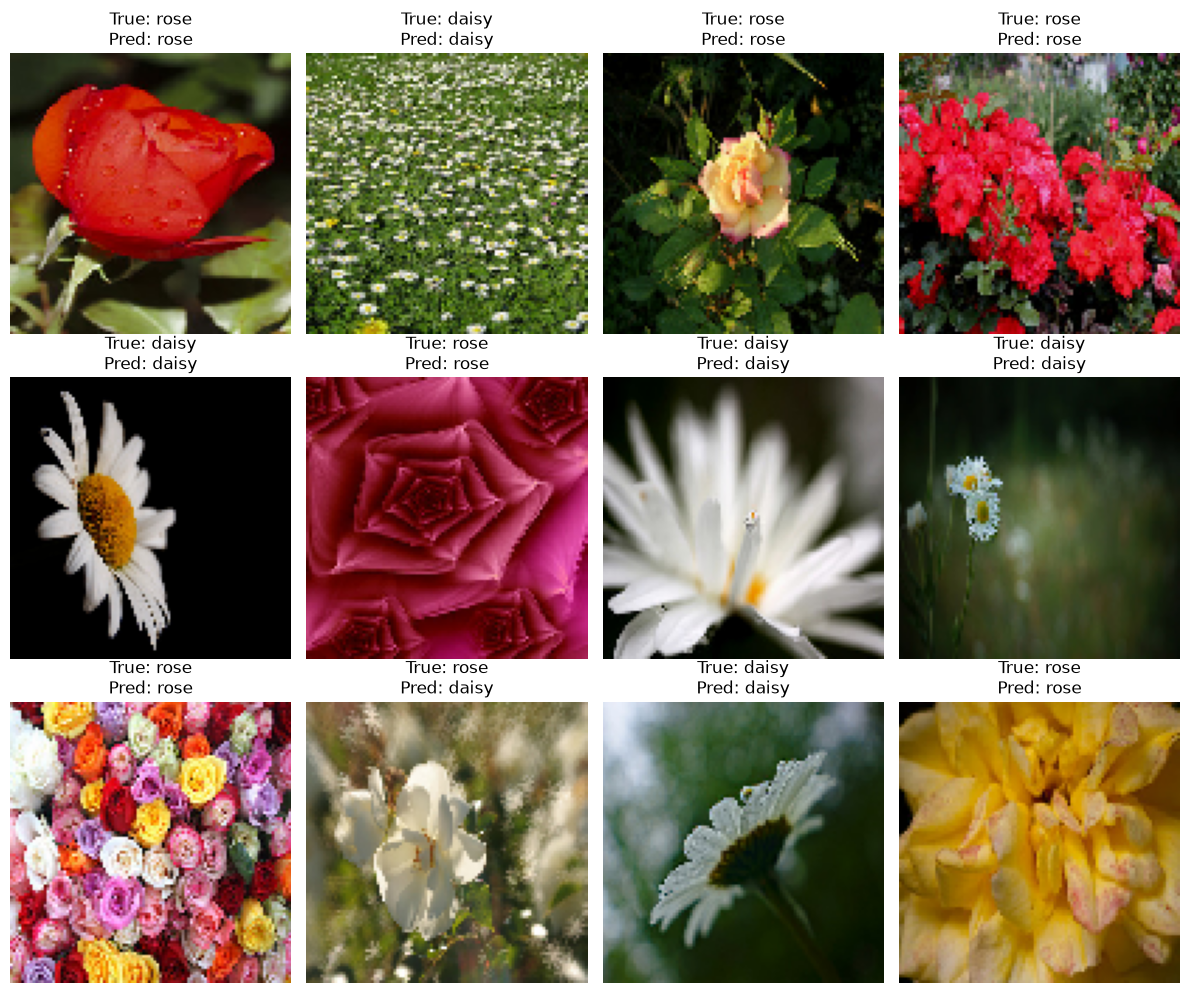

In [36]:
plt.figure(
    figsize=(12, 10)
)

samples = test_df.sample(
    min(12, len(test_df)),
    random_state=42
)

for i, (_, row) in enumerate(
    samples.iterrows()
):

    image = tf.keras.utils.load_img(
        row["path"],
        target_size=(
            IMG_HEIGHT,
            IMG_WIDTH
        )
    )

    array = tf.keras.utils.img_to_array(
        image
    )

    probability = float(
        best_model.predict(
            array[np.newaxis, ...],
            verbose=0
        )[0][0]
    )

    prediction = (
        "rose"
        if probability >= 0.5
        else "daisy"
    )

    plt.subplot(
        3,
        4,
        i + 1
    )

    plt.imshow(image)

    plt.title(
        f"True: {row['class_name']}\n"
        f"Pred: {prediction}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()